## Задание 5

## Часть 1 — Анализ FastQC

Часть 1. Анализ FastQC исходных данных

Для первичного контроля качества исходных FASTQ-файлов был написан SLURM-скрипт 01_fastqc_raw.slurm. Скрипт активировал conda-окружение qc_env, запускал FastQC для всех файлов из директории data/raw и затем объединял отдельные отчёты FastQC в общий отчёт MultiQC.

FastQC был выполнен для четырёх исходных файлов:
- ERR14230573.fastq.gz;
- ERR14230582.fastq.gz;
- ERR14230586.fastq.gz;
- ERR14230595.fastq.gz.

В результате были получены отдельные HTML- и ZIP-отчёты FastQC для каждого файла. Затем MultiQC объединил 4 FastQC-отчёта в один общий отчёт:

results/multiqc_raw/multiqc_raw_report.html

Таким образом, первичный контроль качества исходных данных был успешно выполнен.

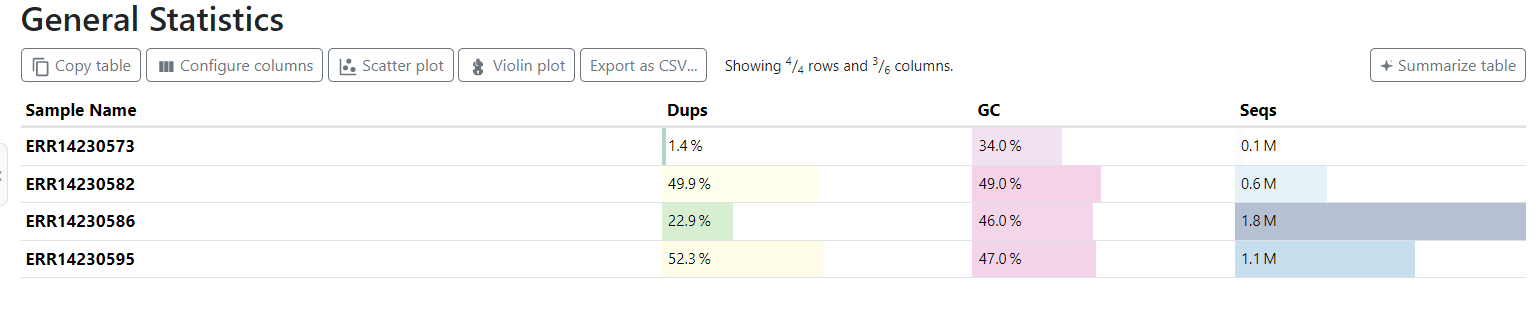

По таблице General Statistics видно, что образцы различались по количеству прочтений, GC-составу и уровню дупликации. Количество прочтений составляло от 0.1M до 1.8M. GC-состав варьировал от 34% до 49%.

Уровень дупликации также различался между образцами:
- ERR14230573 — 1.4%;
- ERR14230582 — 49.9%;
- ERR14230586 — 22.9%;
- ERR14230595 — 52.3%.

Наиболее высокий уровень дупликации наблюдался у ERR14230582 и ERR14230595, что может указывать на пониженную сложность библиотек или наличие большого числа повторяющихся последовательностей.

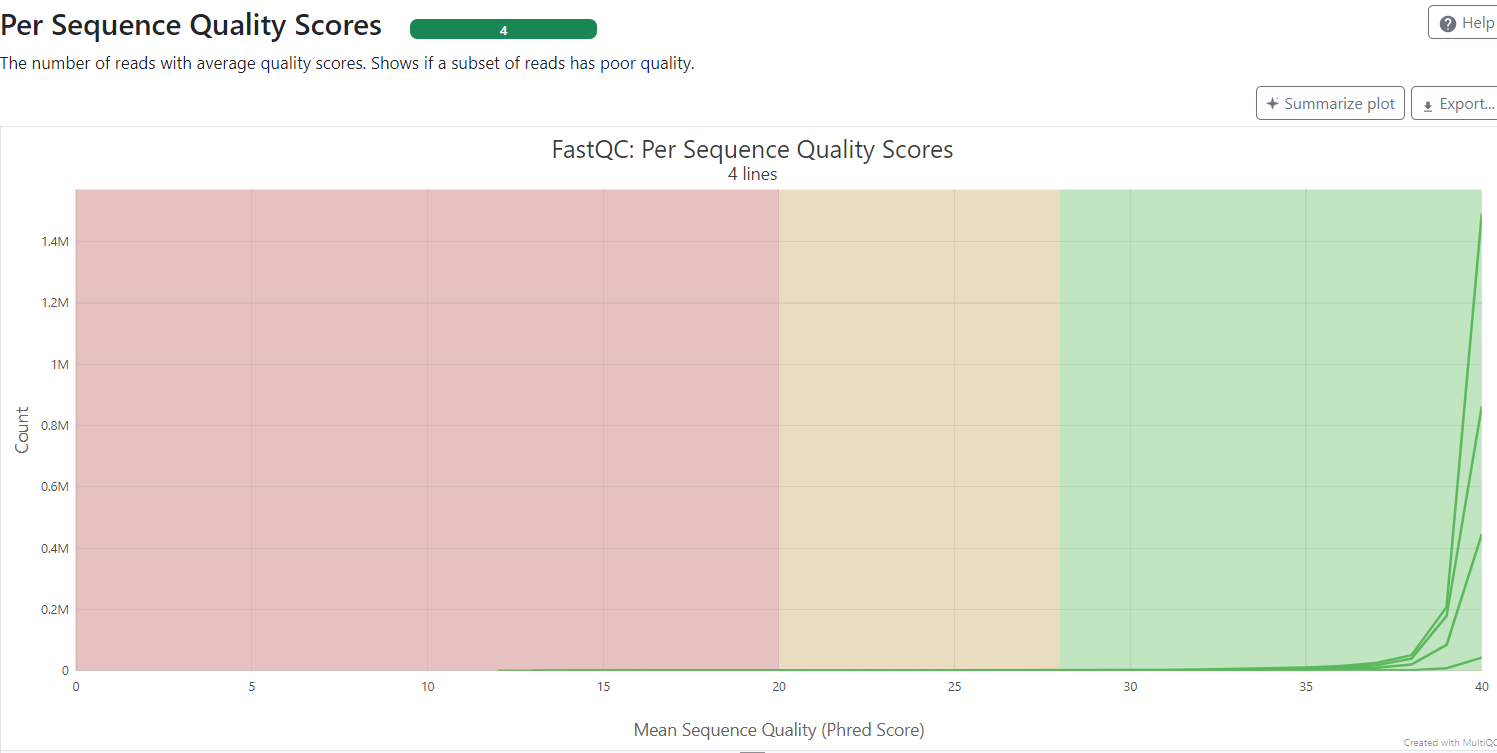

В разделе Per Sequence Quality Scores все 4 образца получили статус PASS. Основная часть прочтений имела высокое среднее качество, преимущественно в зелёной зоне, то есть с Phred score выше Q28–Q30. Это означает, что в целом риды имеют хорошее среднее качество, и выраженной группы прочтений с низким средним качеством не наблюдается.

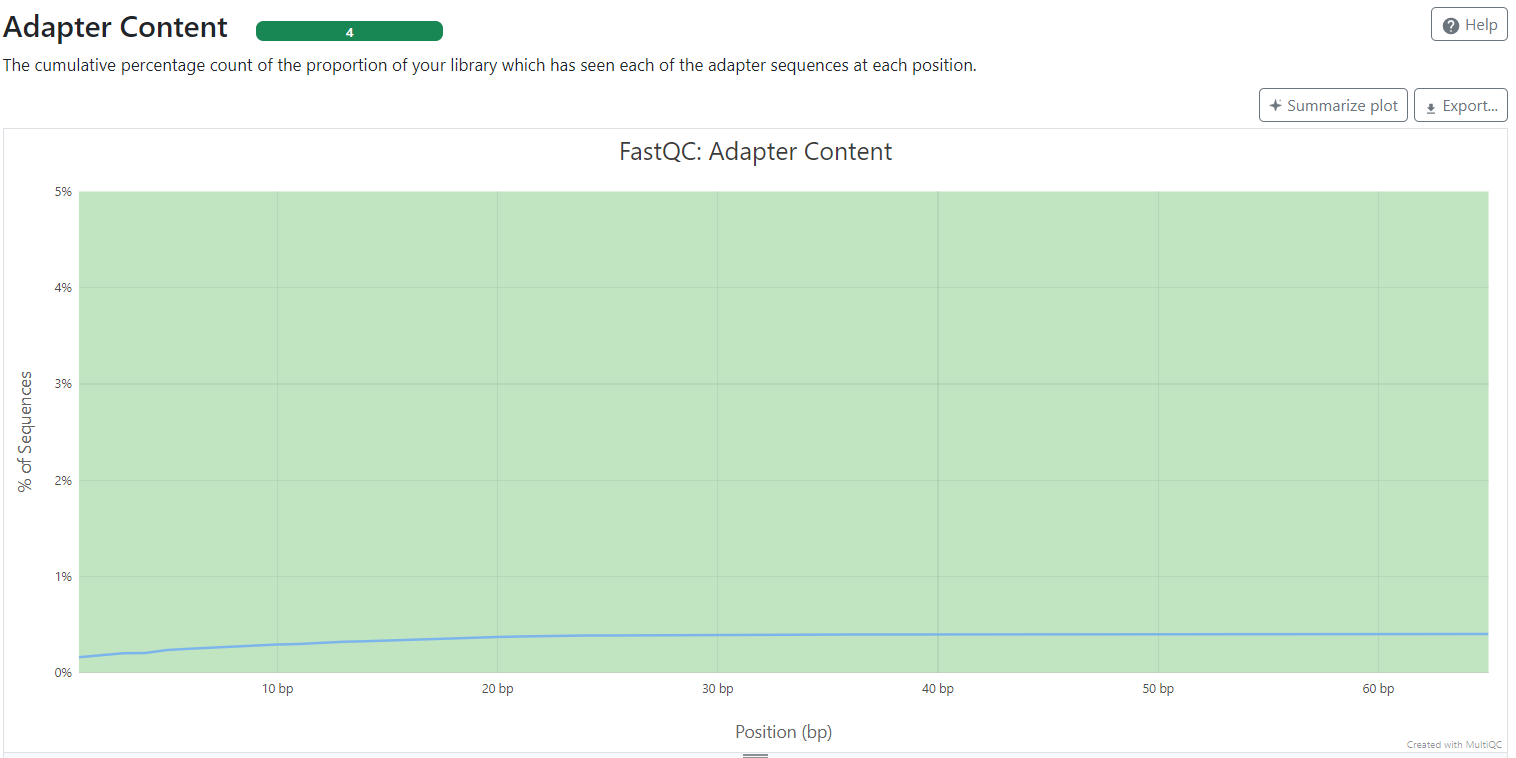

В разделе Adapter Content все 4 образца получили статус PASS. Содержание адаптерных последовательностей было очень низким, менее примерно 0.5% по длине ридов. Следовательно, выраженной проблемы с адаптерами в исходных данных не наблюдалось.

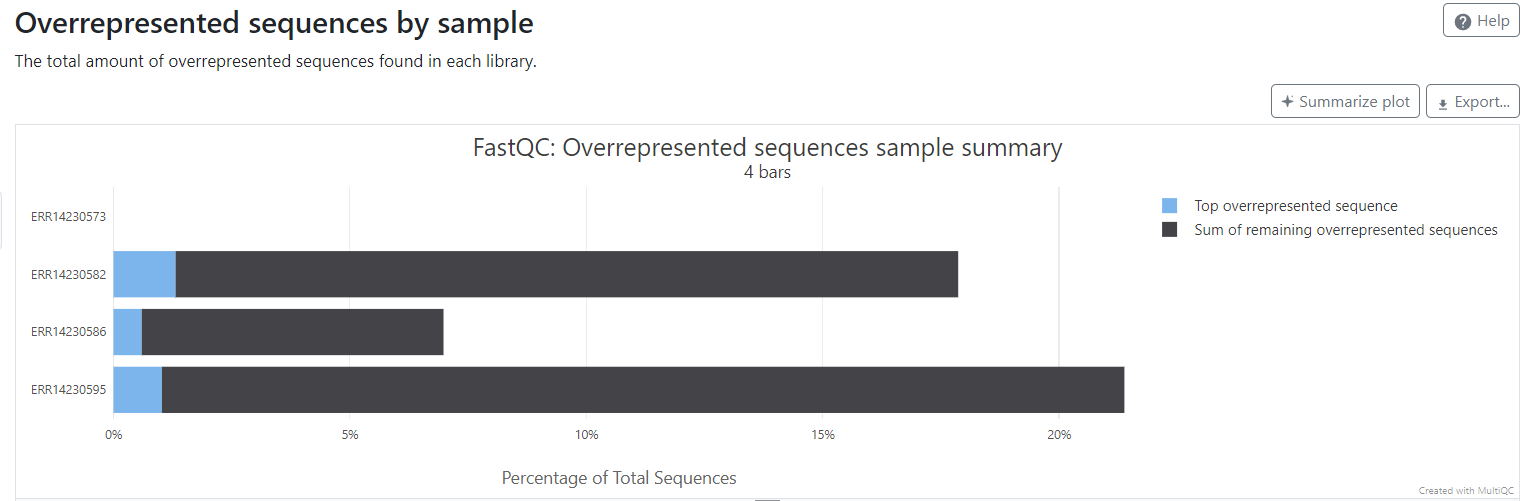

В разделе Overrepresented sequences было обнаружено, что в части образцов присутствует заметная доля переобогащённых последовательностей. Особенно выражена эта проблема в образцах ERR14230595 и ERR14230582, где доля таких последовательностей была наиболее высокой. В ERR14230586 проблема выражена умеренно, а в ERR14230573 практически отсутствует.

Наличие overrepresented sequences может быть связано с низкой сложностью библиотеки, повторяющимися фрагментами или техническими последовательностями.

В отчёте также наблюдалась неоднородность по Per Base Sequence Content и Per Sequence GC Content. Это говорит о том, что состав оснований и GC-распределение различались между образцами. Такие особенности могут быть связаны с типом библиотеки, биологическим составом образцов или техническими особенностями подготовки данных.

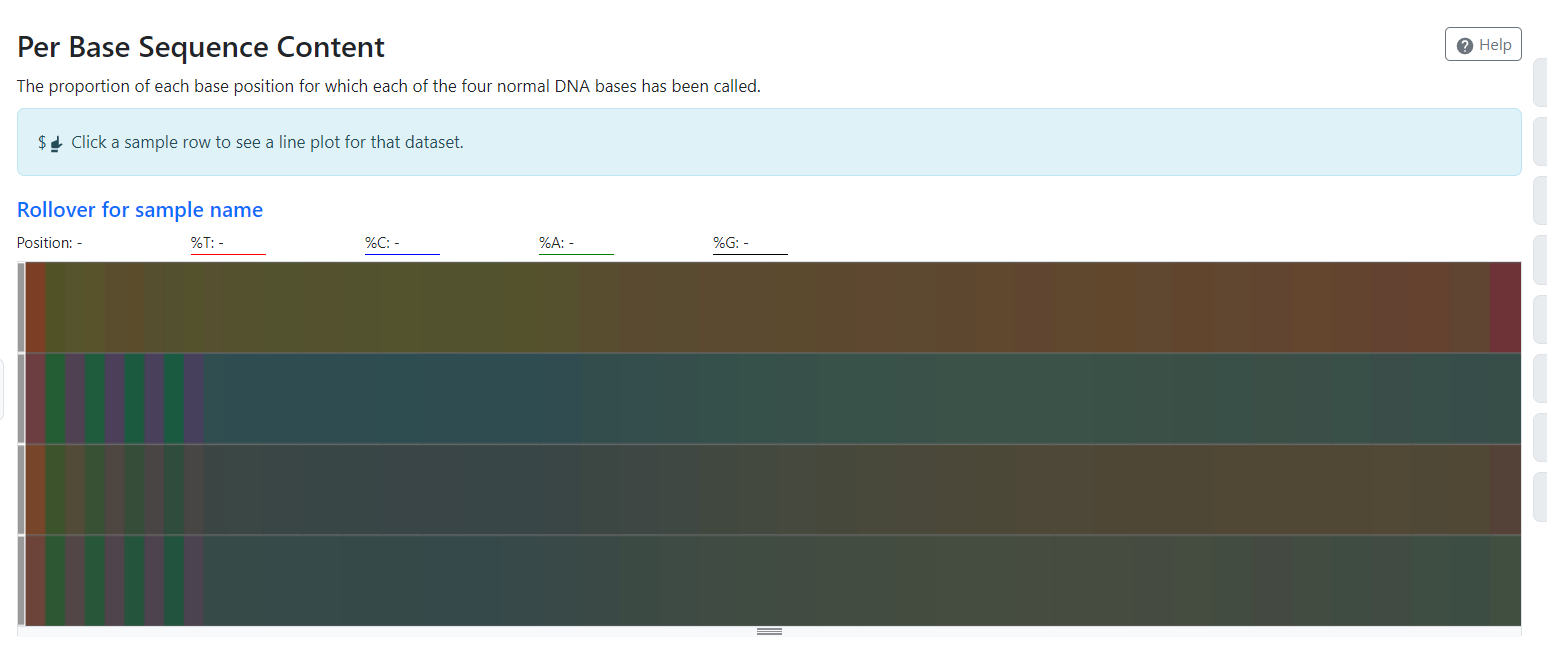

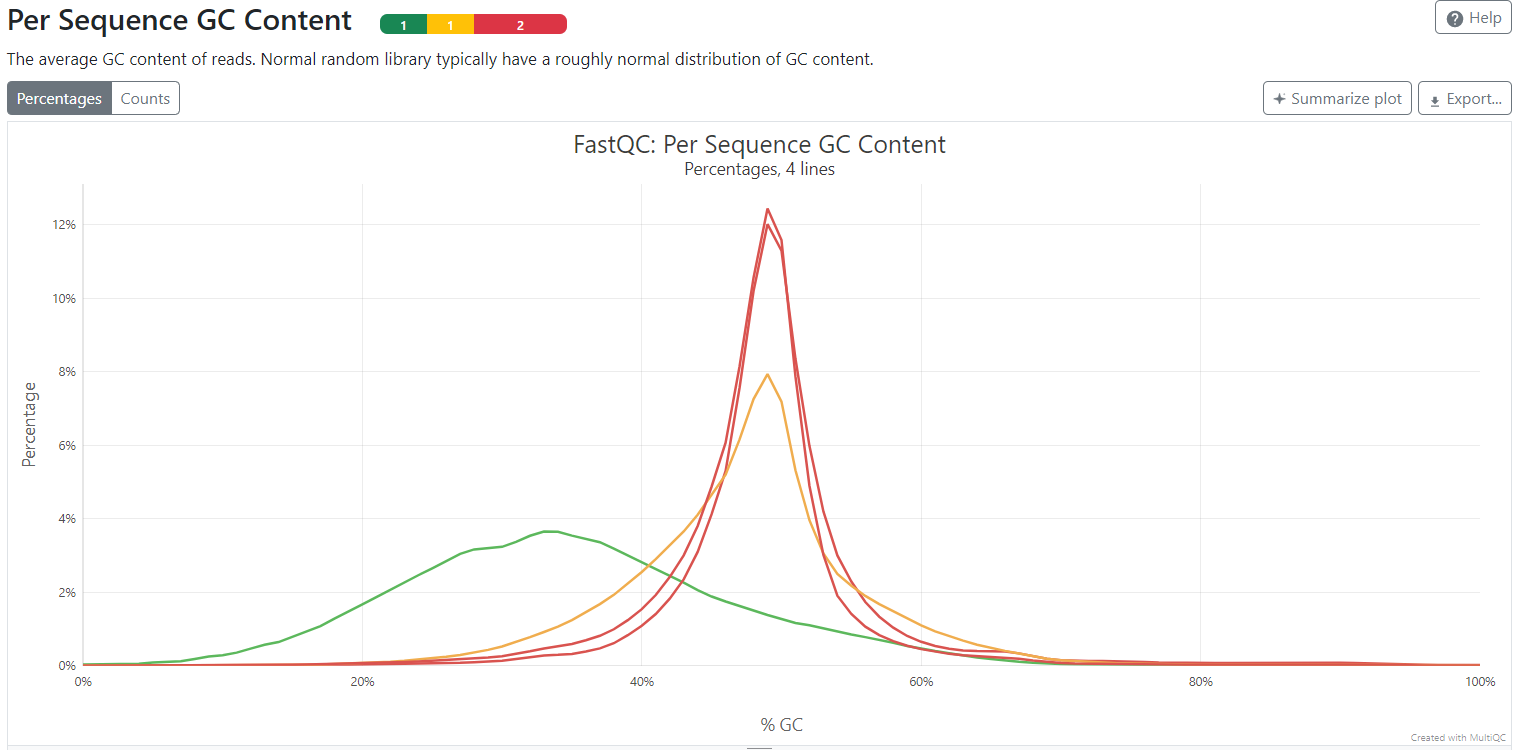

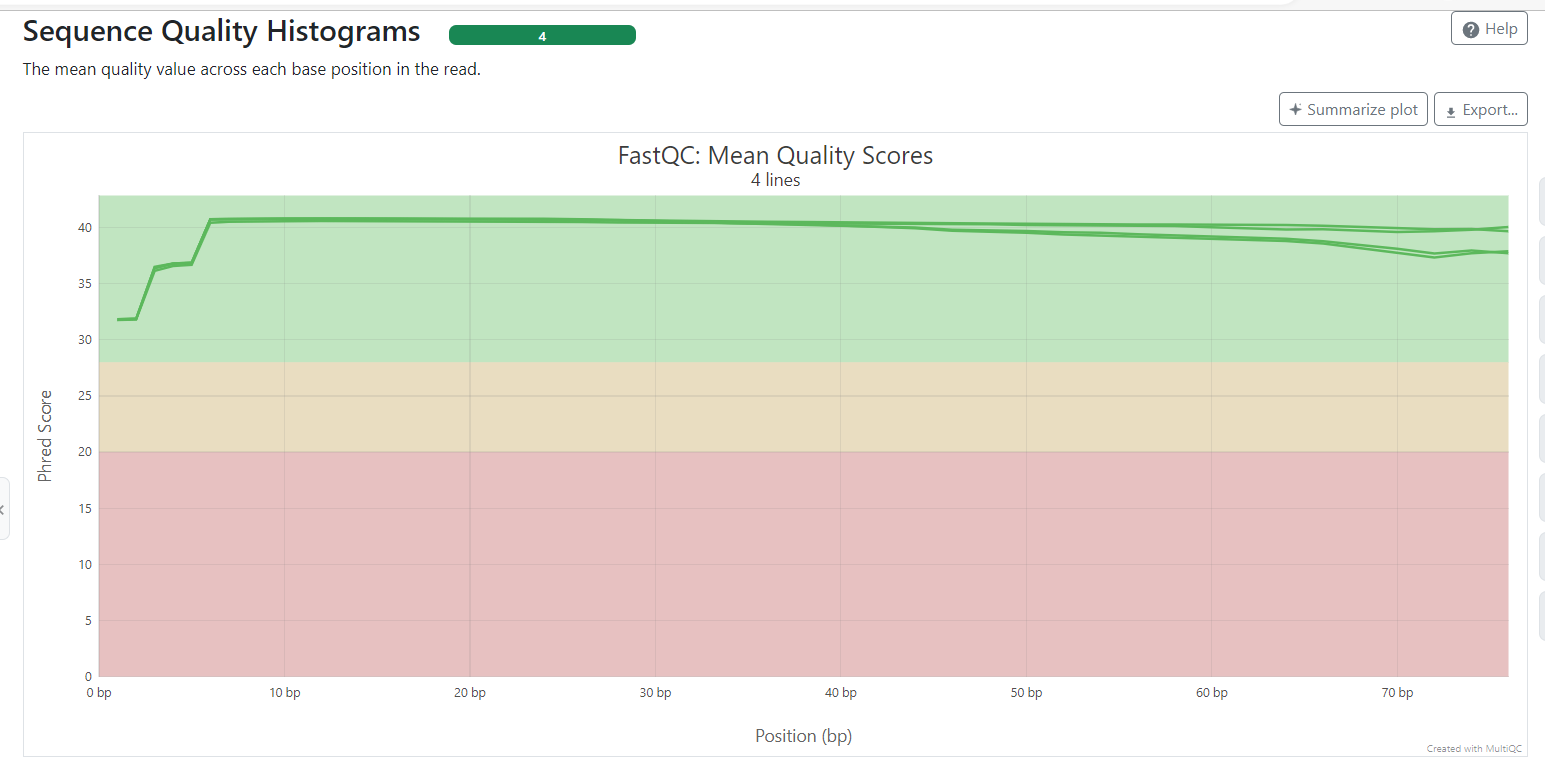

В разделе Sequence Quality Histograms все 4 образца получили статус PASS. Среднее качество оснований по позициям рида было высоким: почти по всей длине прочтений значения Phred score находились примерно в диапазоне Q38–Q41. В начале ридов качество было немного ниже, около Q32–Q36, но всё равно оставалось в зелёной зоне.

На 3'-концах ридов наблюдалось небольшое снижение качества, однако значения качества не опускались ниже Q20. Следовательно, выраженных участков с плохим качеством на концах прочтений в исходных данных не обнаружено. Тем не менее тримминг был выполнен далее согласно требованиям задания.

## SLURM-скрипты

### Скрипт контроля качества до тримминга: `01_fastqc_raw.slurm`

```bash
#!/bin/bash
#SBATCH --partition=AMD9554-common
#SBATCH --job-name=fastqc_raw
#SBATCH --output=logs/fastqc_raw_%j.out
#SBATCH --error=logs/fastqc_raw_%j.err
#SBATCH --time=02:00:00
#SBATCH --cpus-per-task=4
#SBATCH --mem=8G

cd $HOME/bioinf_hw_5_fastqc

source $HOME/miniforge3/etc/profile.d/conda.sh
conda activate qc_env

mkdir -p results/fastqc_raw
mkdir -p results/multiqc_raw

fastqc \
  -t ${SLURM_CPUS_PER_TASK} \
  -o results/fastqc_raw \
  data/raw/*.fastq.gz

multiqc \
  results/fastqc_raw \
  -o results/multiqc_raw \
  -n multiqc_raw_report.html
```


## Часть 2 — Тримминг

### SLURM-скрипты для тримминга и контроля после тримминга

### Скрипт тримминга: `02_fastp_trim_single.slurm`

```bash
#!/bin/bash
#SBATCH --partition=AMD9554-common
#SBATCH --job-name=fastp_trim
#SBATCH --output=logs/fastp_trim_%j.out
#SBATCH --error=logs/fastp_trim_%j.err
#SBATCH --time=02:00:00
#SBATCH --cpus-per-task=4
#SBATCH --mem=8G

cd $HOME/bioinf_hw_5_fastqc

source $HOME/miniforge3/etc/profile.d/conda.sh
conda activate qc_env

mkdir -p data/trimmed
mkdir -p results/fastp

for fq in data/raw/*.fastq.gz
do
    sample=$(basename "$fq" .fastq.gz)

    fastp \
      -i "$fq" \
      -o "data/trimmed/${sample}_trimmed.fastq.gz" \
      --cut_right \
      --cut_window_size 5 \
      --cut_mean_quality 20 \
      --length_required 36 \
      --thread ${SLURM_CPUS_PER_TASK} \
      --html "results/fastp/${sample}_fastp.html" \
      --json "results/fastp/${sample}_fastp.json"
done
```


### Скрипт контроля качества после тримминга: `03_fastqc_trimmed.slurm`

```bash
#!/bin/bash
#SBATCH --partition=AMD9554-common
#SBATCH --job-name=fastqc_trimmed
#SBATCH --output=logs/fastqc_trimmed_%j.out
#SBATCH --error=logs/fastqc_trimmed_%j.err
#SBATCH --time=02:00:00
#SBATCH --cpus-per-task=4
#SBATCH --mem=8G

cd $HOME/bioinf_hw_5_fastqc

source $HOME/miniforge3/etc/profile.d/conda.sh
conda activate qc_env

mkdir -p results/fastqc_trimmed
mkdir -p results/multiqc_trimmed

fastqc \
  -t ${SLURM_CPUS_PER_TASK} \
  -o results/fastqc_trimmed \
  data/trimmed/*_trimmed.fastq.gz

multiqc \
  results/fastqc_trimmed \
  -o results/multiqc_trimmed \
  -n multiqc_trimmed_report.html
```


По результатам первичного MultiQC-отчёта было установлено, что выраженной проблемы с адаптерами в исходных данных не наблюдалось: все 4 образца получили статус PASS в разделе Adapter Content, а доля адаптерных последовательностей была очень низкой.

Также по разделу Sequence Quality Histograms было видно, что качество оснований по всей длине ридов оставалось выше Q20. На 3'-концах ридов наблюдалось только небольшое снижение качества, но значения не опускались ниже Q20.

Тримминг был выполнен согласно требованиям задания. Для обработки использовалась программа fastp. Так как данные были single-end, каждый FASTQ-файл обрабатывался отдельно. Для single-end данных fastp выполняет автоматическое определение и обрезку адаптеров по умолчанию.

В SLURM-скрипте fastp были использованы следующие параметры:
- `--cut_right` — обрезка низкокачественных участков с использованием скользящего окна;
- `--cut_window_size 5` — размер скользящего окна 5 нуклеотидов;
- `--cut_mean_quality 20` — минимальное среднее качество в окне Q20;
- `--length_required 36` — удаление ридов короче 36 п.н.;
- выходные файлы сохранялись с суффиксом `_trimmed.fastq.gz`.

После выполнения тримминга были получены 4 очищенных FASTQ-файла в директории `data/trimmed`:
- `ERR14230573_trimmed.fastq.gz`;
- `ERR14230582_trimmed.fastq.gz`;
- `ERR14230586_trimmed.fastq.gz`;
- `ERR14230595_trimmed.fastq.gz`.

Также для каждого образца были созданы отчёты fastp в форматах HTML и JSON в директории `results/fastp`.


Наличие очищенных файлов после тримминга было проверено командой:
ls -la --time=ctime data/trimmed

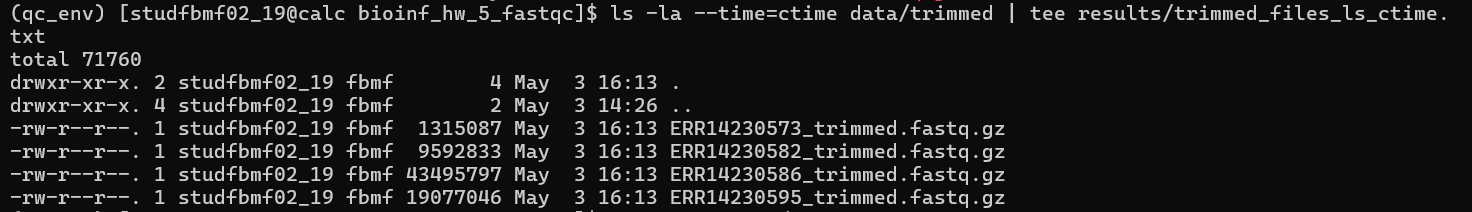

## Часть 3 — Контроль качества после тримминга

После выполнения тримминга очищенные файлы *_trimmed.fastq.gz были повторно проанализированы с помощью FastQC. Для запуска был написан SLURM-скрипт 03_fastqc_trimmed.slurm, который активировал conda-окружение qc_env, запускал FastQC для всех файлов из директории data/trimmed и затем объединял отчёты в общий MultiQC-отчёт.

FastQC был выполнен для следующих очищенных файлов:
- ERR14230573_trimmed.fastq.gz;
- ERR14230582_trimmed.fastq.gz;
- ERR14230586_trimmed.fastq.gz;
- ERR14230595_trimmed.fastq.gz.

В результате были получены отдельные FastQC-отчёты в директории results/fastqc_trimmed и общий отчёт MultiQC:
results/multiqc_trimmed/multiqc_trimmed_report.html.

### Сравнение General Statistics до и после тримминга

После тримминга количество прочтений уменьшилось во всех образцах. Это ожидаемо, так как fastp удалял риды, которые после обрезки становились короче 36 п.н., а также выполнял фильтрацию низкокачественных участков.

До тримминга:
- ERR14230573: 0.1M reads, duplicates 1.4%, GC 34%;
- ERR14230582: 0.6M reads, duplicates 49.9%, GC 49%;
- ERR14230586: 1.8M reads, duplicates 22.9%, GC 46%;
- ERR14230595: 1.1M reads, duplicates 52.3%, GC 47%.

После тримминга:
- ERR14230573: 0.0M reads, duplicates 1.3%, GC 35%;
- ERR14230582: 0.4M reads, duplicates 42.6%, GC 49%;
- ERR14230586: 1.5M reads, duplicates 16.8%, GC 46%;
- ERR14230595: 0.8M reads, duplicates 47.1%, GC 47%.

Для ERR14230573 количество прочтений после тримминга в MultiQC отображается как 0.0M из-за округления, однако очищенный файл был создан и присутствует в папке `data/trimmed`.

GC-состав после тримминга практически не изменился: для большинства образцов он остался таким же, а для ERR14230573 изменился только с 34% до 35%. Это говорит о том, что тримминг не внёс заметного смещения в нуклеотидный состав данных.

Доля дупликации после тримминга снизилась:
- ERR14230582: с 49.9% до 42.6%;
- ERR14230586: с 22.9% до 16.8%;
- ERR14230595: с 52.3% до 47.1%;
- ERR14230573: практически не изменилась, с 1.4% до 1.3%.

Таким образом, после тримминга метрики немного улучшились: уменьшилась доля дупликации и были удалены часть ридов, не прошедших фильтры fastp. При этом GC-состав остался стабильным, что указывает на корректность обработки.


до тримминга
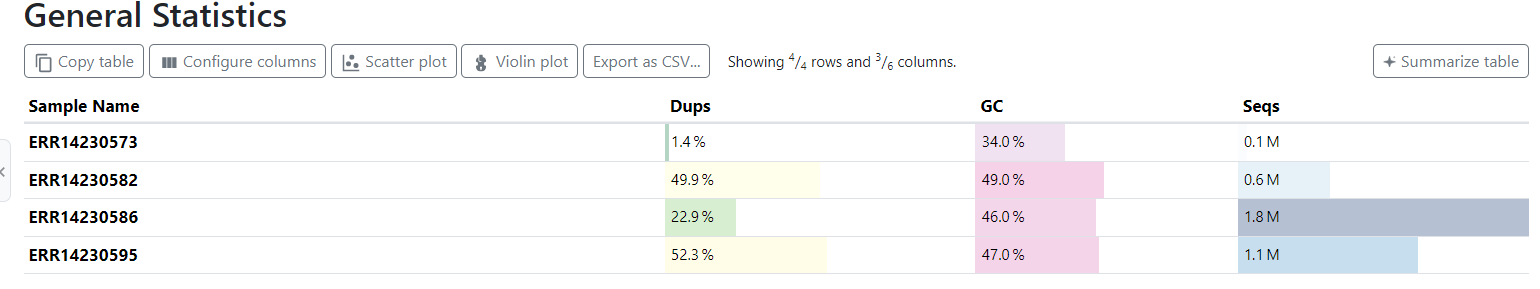

после тримминга
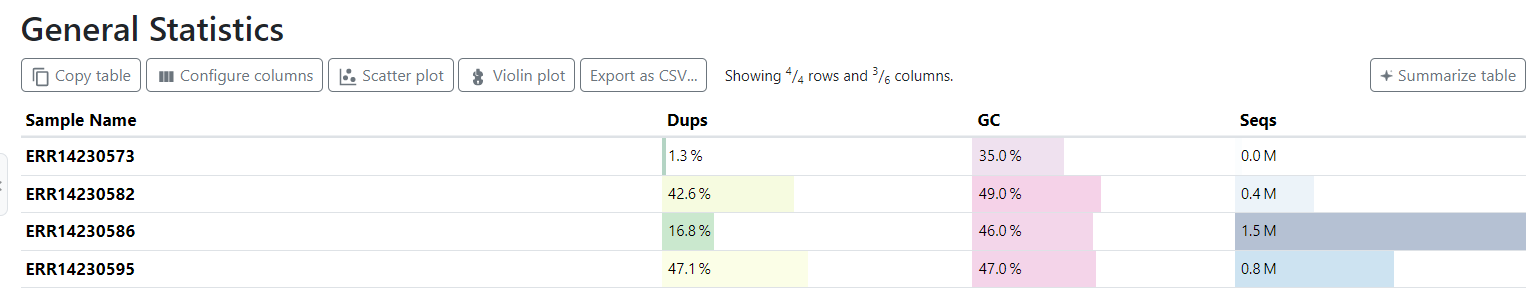

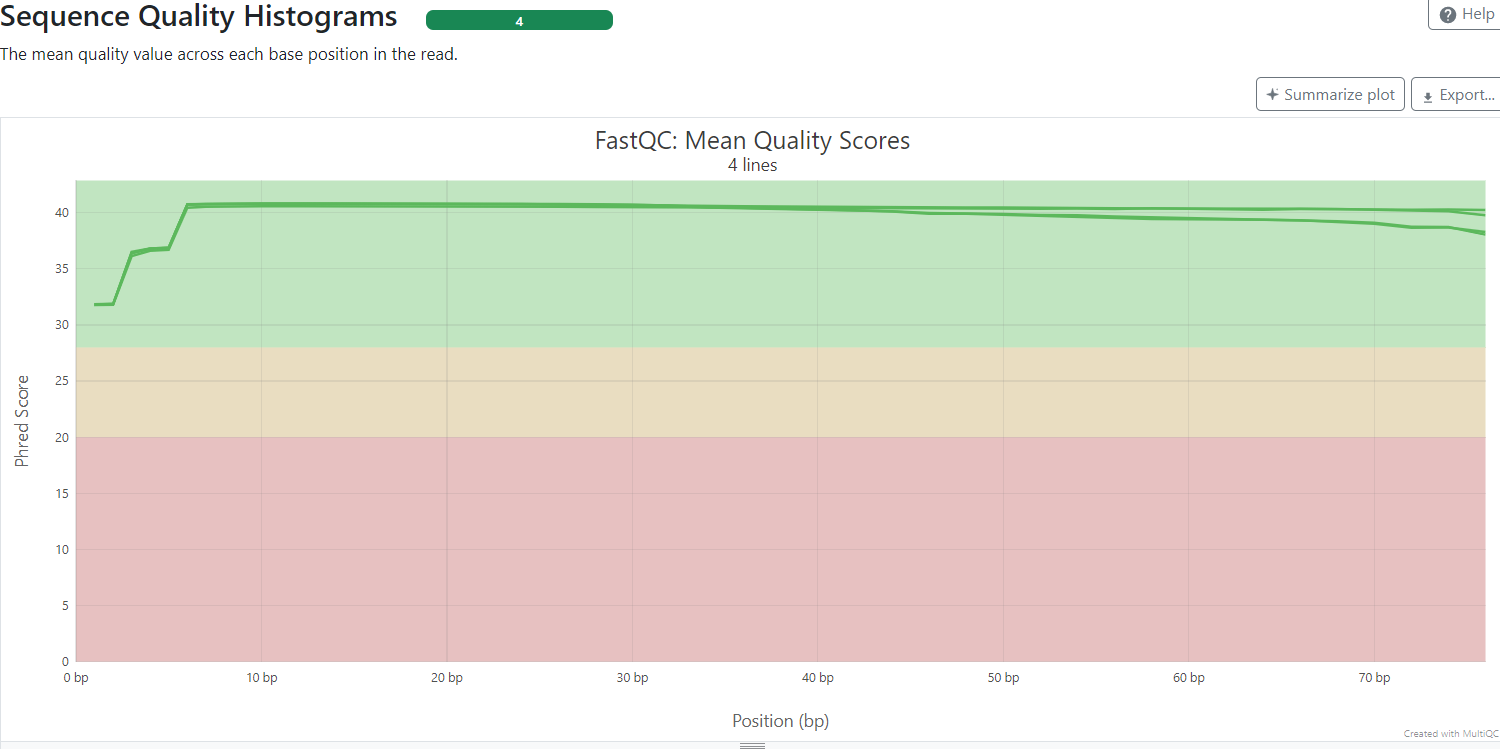

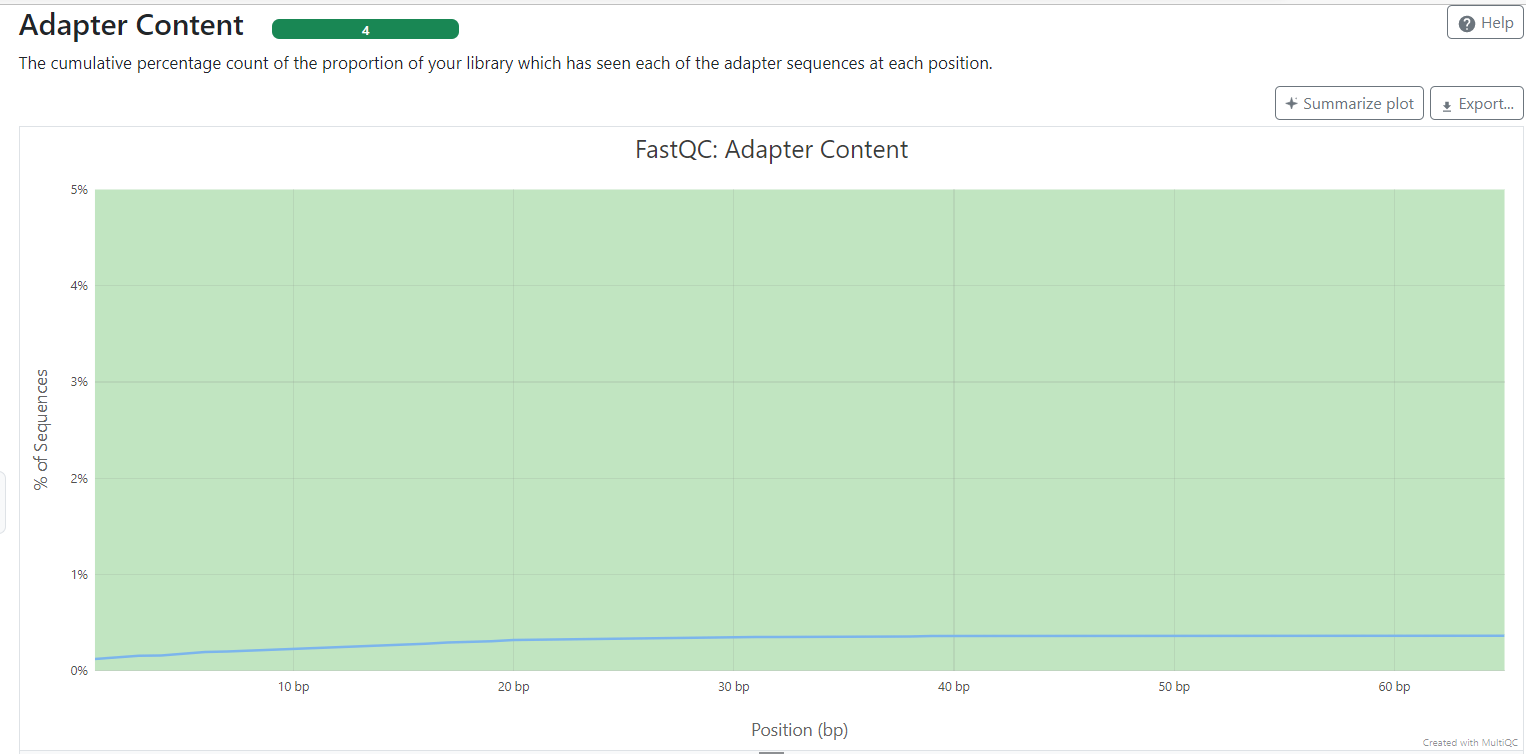

После тримминга Sequence Quality Histograms и Adapter Content сохранили статус PASS для всех 4 образцов. Это подтверждает, что данные после очистки остались высокого качества.

## Выводы

В ходе работы были скачаны 4 ERR-run из проекта PRJEB84057 и выполнен первичный контроль качества с помощью FastQC. Отдельные отчёты FastQC были объединены в общий отчёт MultiQC.

Первичный анализ показал, что исходные данные имели хорошее качество: в разделе Sequence Quality Histograms все 4 образца получили статус PASS, а среднее качество оснований по всей длине ридов оставалось выше Q20. Выраженной проблемы с адаптерами обнаружено не было, так как все образцы получили PASS в разделе Adapter Content.

Основные проблемные особенности исходных данных были связаны не с качеством ридов, а с повышенной дупликацией и наличием overrepresented sequences в части образцов, особенно в ERR14230582 и ERR14230595.

Далее был выполнен тримминг с помощью fastp. Были применены скользящее окно 5:20, фильтрация ридов короче 36 п.н. и сохранение очищенных файлов с суффиксом `_trimmed.fastq.gz`.

После тримминга был повторно выполнен FastQC и собран новый MultiQC-отчёт. Сравнение отчётов до и после показало, что качество данных осталось высоким. Количество прочтений уменьшилось, что связано с фильтрацией и удалением ридов короче 36 п.н. GC-состав практически не изменился, а уровень дупликации снизился в большинстве образцов. Таким образом, метрики после тримминга немного улучшились, особенно по уровню дупликации.
